<a href="https://colab.research.google.com/github/falseywinchnet/EpistemicGPT/blob/main/Physics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Initializing Local Vocab Physics Demo...
Training...


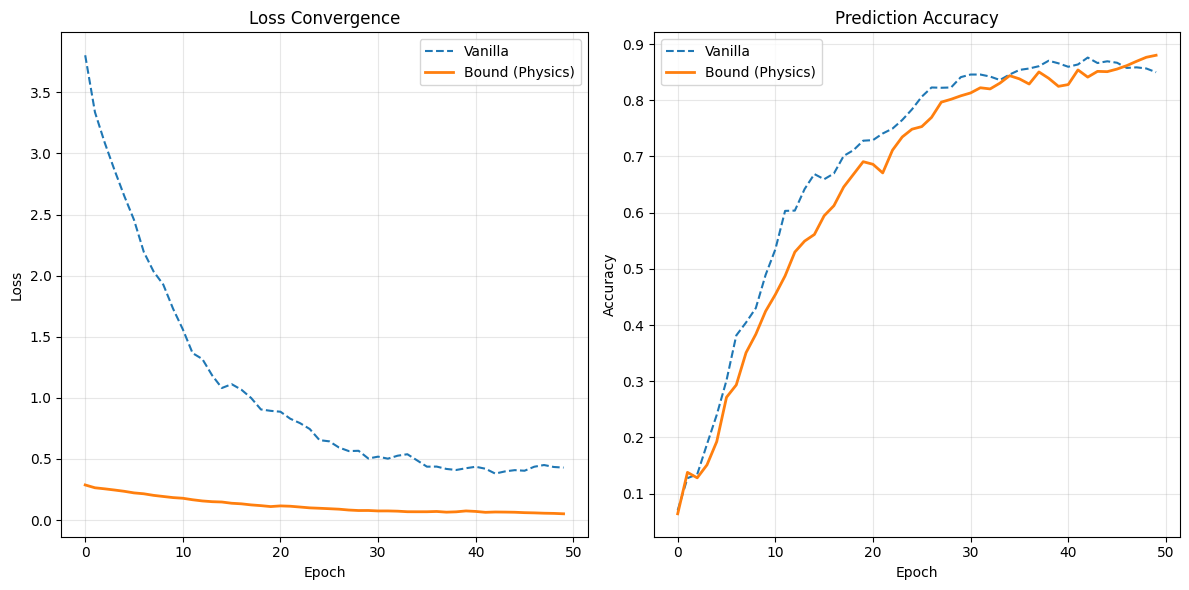

Final Vanilla Acc: 85.0%
Final Bound Acc:   88.0%


In [25]:
#copyright 2026 joshuah.rainstar@gmail.com MIT take it do whatever u like with it
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size):
        super().__init__()
        self.wte = nn.Embedding(vocab_size, n_embd)
        self.blocks = nn.ModuleList([
            nn.TransformerEncoderLayer(d_model=n_embd, nhead=n_head, dim_feedforward=4*n_embd,
                                       dropout=0.0, activation='gelu', batch_first=True, norm_first=True)
            for _ in range(n_layer)
        ])
        self.ln_f = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)

    def forward(self, idx):
        mask = torch.triu(torch.ones(idx.size(1), idx.size(1), device=idx.device) * float('-inf'), diagonal=1)
        x = self.wte(idx)
        for block in self.blocks:
            x = block(x, src_mask=mask)
        return self.lm_head(self.ln_f(x))

class DynamicLocalPhysics(nn.Module):
    """
    Computes the 'Base System' Energy Limit using a Local Vocabulary approach.
    This avoids O(V) memory usage, scaling instead with the context length O(T).
    """
    def __init__(self):
        super().__init__()

    def forward(self, logits, targets, input_ids):
        """
        input_ids: [B, T] - The full context window
        logits:    [B, T, V] - Model predictions
        targets:   [B, T] - Ground truth
        """
        B, T = input_ids.shape

        # --- 1. Map Global IDs to Local Vocab ---
        # We only care about tokens present in this batch's history
        flat_input = input_ids.view(-1)
        unique_tokens, inverse_indices = torch.unique(flat_input, return_inverse=True)
        local_ids = inverse_indices.view(B, T)
        V_local = len(unique_tokens)

        # --- 2. Compute Base System Mixtures (Vectorized) ---

        # A. Create Distance Weights Matrix [T, T]
        # dists[i, j] is distance from j to i.
        indices = torch.arange(T, device=input_ids.device)
        diffs = indices.unsqueeze(1) - indices.unsqueeze(0)
        dists = diffs + 1.0 # Distance 1, 2, 3...

        # Mask future (causal) and convert to recency score 1/d
        causal_mask = torch.tril(torch.ones(T, T, device=input_ids.device))
        recency_weights = (1.0 / dists) * causal_mask # [T, T]

        # B. Accumulate Scores into Local Vocab [B, T, V_local]
        # We want: mix[b, t, v] = sum(recency_weights[t, k]) where local_ids[b, k] == v

        # Initialize scores tensor
        # This is small: [1, 64, ~40] for the demo
        local_scores = torch.zeros(B, T, V_local, device=input_ids.device)

        # Scatter Add
        # We iterate T to broadcast the weights correctly for each timestep's history
        # (Fully vectorizing this 3D scatter is complex, loop over T is efficient for T=64)
        for t in range(T):
            # History up to t: [B, t+1]
            hist_ids = local_ids[:, :t+1]
            # Weights for this history: [t+1]
            w = recency_weights[t, :t+1]

            # Broadcast weights: [B, t+1]
            w_batch = w.unsqueeze(0).expand(B, -1)

            # Scatter into the t-th slice of scores
            local_scores[:, t, :].scatter_add_(1, hist_ids, w_batch)

        # --- 3. Compute Energy (Transition t -> t+1) ---
        # We process t from 0 to T-2 (predicting 1..T-1)
        # Note: We need the TARGET for t+1 to promote it in the mixture at t

        energies = []

        # To compute L1(Mix_t, Mix_{t+1}), we need both mixtures fully constructed.
        # Let's construct the "Promoted Mixtures" for all valid t first.

        # Targets for position t (which predict t+1) are local_ids[:, t+1]
        # We can do this for t=0..T-2
        valid_steps = T - 1

        # We need a tensor of mixtures [B, valid_steps, V_local]
        # Copy base scores
        mixtures = local_scores[:, :valid_steps, :].clone()

        # Add 1.0 to the Future Token (Target)
        # Targets: local_ids[:, 1:]
        future_tokens = local_ids[:, 1:T] # [B, T-1]

        # Scatter add 1.0
        # dim 2 is vocab
        mixtures.scatter_add_(2, future_tokens.unsqueeze(2), torch.ones(B, valid_steps, 1, device=input_ids.device))

        # Softmax to get probability distributions
        # Note: Unseen tokens in local_vocab have score 0 -> exp(0)=1.
        # This is correct: they have a non-zero probability "floor" in this interpretation.
        # If strict 0 is desired, we would mask, but "softmax over current past" usually implies
        # a distribution over the *possible* space, biased by history.
        distributions = F.softmax(mixtures, dim=-1) # [B, T-1, V_local]

        # Calculate Wasserstein (L1) Energy
        # E[t] = |Dist[t] - Dist[t-1]|
        # For t=0, we compare against a "start" state (e.g., zeros or uniform)
        # We'll use the first distribution itself as baseline (Energy=1.0) or diff with adjacent.
        # The prompt implies calculating the diff between t and t+1.
        # Dist[t] predicts t+1. Dist[t+1] predicts t+2.
        # So we compare distributions[:, t, :] and distributions[:, t+1, :]

        # We can compute vectorized diff for t=0..T-3
        # Dists: [B, 0..T-2]
        d_current = distributions[:, :-1, :] # 0..T-3
        d_next    = distributions[:, 1:, :]  # 1..T-2

        # L1 sum over vocab
        energy_vec = torch.abs(d_next - d_current).sum(dim=-1) # [B, T-2]

        # Prepend an initial energy kick for the first step
        initial_kick = torch.ones(B, 1, device=input_ids.device)
        energy_limit = torch.cat([initial_kick, energy_vec], dim=1) # [B, T-1]

        # --- 4. Dynamic Gradient Scaling ---

        # Align Logits/Targets to the valid energy length (T-1)
        # Logits [B, T, V] -> [B, T-1, V] (Predicting 1..T)
        # But wait, Energy[t] is transition t->t+1. It constrains loss at t.
        # We have energy for 0..T-2.
        # This matches logits predicting targets at 1..T-1.
        # We lose the very last token prediction because we can't see *its* future to compute energy.

        valid_logits = logits[:, :valid_steps, :]
        valid_targets = targets[:, :valid_steps]

        # Raw Cross Entropy
        raw_loss = F.cross_entropy(
            valid_logits.reshape(-1, valid_logits.size(-1)),
            valid_targets.reshape(-1),
            reduction='none'
        ).view(B, valid_steps)

        # Scaling: Loss <= Energy
        # scale = energy / loss
        scale = energy_limit / (raw_loss **0.5 + 1e-6)
        scale = torch.clamp(scale, max=1.0)

        # Apply Scale (Detached)
        final_loss = raw_loss * scale.detach()

        return final_loss.mean(), valid_logits, valid_targets

# --- Experiment ---
def run_local_vocab_demo():
    print("Initializing Local Vocab Physics Demo...")
    vocab_size = 40
    seq_len = 2000
    block_size = 64

    # Generate Induction Data
    data = torch.randint(0, vocab_size, (seq_len,)).to(device)
    for i in range(10, seq_len-1):
        if torch.rand(1) < 0.7:
            curr = data[i]
            locs = (data[:i] == curr).nonzero(as_tuple=True)[0]
            if len(locs) > 0:
                data[i+1] = data[locs[-1]+1]

    # Models
    model_v = GPT(vocab_size, 64, 4, 2, block_size).to(device)
    model_b = copy.deepcopy(model_v)

    opt_v = torch.optim.AdamW(model_v.parameters(), lr=0.005)
    opt_b = torch.optim.AdamW(model_b.parameters(), lr=0.005)

    criterion = DynamicLocalPhysics()

    history = {'v_loss': [], 'b_loss': [], 'v_acc': [], 'b_acc': []}
    num_blocks = (seq_len - 1) // block_size

    print("Training...")
    for epoch in range(50):
        m = {k: 0.0 for k in history}

        for i in range(num_blocks):
            start = i * block_size
            end = start + block_size

            x = data[start:end].unsqueeze(0)
            y = data[start+1:end+1].unsqueeze(0)

            # --- Vanilla ---
            logits_v = model_v(x)
            # Slice to match Bound model's effective length (T-1)
            eff_len = logits_v.size(1) - 1
            lv = F.cross_entropy(logits_v[:, :eff_len].reshape(-1, vocab_size), y[:, :eff_len].reshape(-1))

            opt_v.zero_grad(); lv.backward(); opt_v.step()

            acc_v = (logits_v[:, :eff_len].argmax(-1) == y[:, :eff_len]).float().mean()
            m['v_loss'] += lv.item()
            m['v_acc'] += acc_v.item()

            # --- Bound (Physics) ---
            logits_b = model_b(x)

            # The Magic happens here: Recomputed, Local-Vocab Physics
            lb, val_log, val_targ = criterion(logits_b, y, x)

            opt_b.zero_grad(); lb.backward(); opt_b.step()

            acc_b = (val_log.argmax(-1) == val_targ).float().mean()
            m['b_loss'] += lb.item()
            m['b_acc'] += acc_b.item()

        for k in history:
            history[k].append(m[k] / num_blocks)

    # --- Plot ---
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.plot(history['v_loss'], label='Vanilla', linestyle='--')
    plt.plot(history['b_loss'], label='Bound (Physics)', linewidth=2)
    plt.title("Loss Convergence")
    plt.ylabel("Loss")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.plot(history['v_acc'], label='Vanilla', linestyle='--')
    plt.plot(history['b_acc'], label='Bound (Physics)', linewidth=2)
    plt.title("Prediction Accuracy")
    plt.ylabel("Accuracy")
    plt.xlabel("Epoch")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Final Vanilla Acc: {history['v_acc'][-1]*100:.1f}%")
    print(f"Final Bound Acc:   {history['b_acc'][-1]*100:.1f}%")

run_local_vocab_demo()